In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2FsYWwvRGVza3RvcC9jb2RlL2NyYWJieW1ldHJpY3MvZG9jcy9hYmxhdGlvbnM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap.py": 1743382022.7735002, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap_external.py": 1743382022.7737157, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/zipimport.py": 1743382022.8471594, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/codecs.py": 1743382022.716922, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/aliases.py": 1743382022.7266889, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/__init__.py": 1743382022.7262201, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/utf_8.py": 1743382022.7358487, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/abc.py": 1743382022.7091

In [2]:
from html import escape

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

import crabbymetrics as cm

np.set_printoptions(precision=4, suppress=True)


def html_table(headers, rows):
    parts = [
        "<table>",
        "<thead>",
        "<tr>",
        *[f"<th>{escape(str(header))}</th>" for header in headers],
        "</tr>",
        "</thead>",
        "<tbody>",
    ]
    for row in rows:
        parts.append("<tr>")
        for cell in row:
            parts.append(f"<td>{cell}</td>")
        parts.append("</tr>")
    parts.extend(["</tbody>", "</table>"])
    return "".join(parts)


def expit(x):
    return 1.0 / (1.0 + np.exp(-x))


def summarize_interval(estimates, ses, truth):
    estimates = np.asarray(estimates)
    ses = np.asarray(ses)
    covered = np.abs(estimates - truth) <= 1.96 * ses
    return {
        "mean_estimate": float(estimates.mean()),
        "bias": float(estimates.mean() - truth),
        "abs_bias": float(abs(estimates.mean() - truth)),
        "empirical_sd": float(estimates.std(ddof=1)),
        "mean_se": float(ses.mean()),
        "rmse": float(np.sqrt(np.mean((estimates - truth) ** 2))),
        "coverage": float(covered.mean()),
    }


def summarize_point(estimates, truth):
    estimates = np.asarray(estimates)
    return {
        "mean_estimate": float(estimates.mean()),
        "bias": float(estimates.mean() - truth),
        "abs_bias": float(abs(estimates.mean() - truth)),
        "empirical_sd": float(estimates.std(ddof=1)),
        "rmse": float(np.sqrt(np.mean((estimates - truth) ** 2))),
    }


def plot_metric(ax, results, metric, title, ylabel):
    sample_sizes = sorted({entry["n"] for entry in results})
    methods = []
    for entry in results:
        if entry["method"] not in methods:
            methods.append(entry["method"])

    for method in methods:
        values = [
            next(entry[metric] for entry in results if entry["n"] == n and entry["method"] == method)
            for n in sample_sizes
        ]
        ax.plot(sample_sizes, values, marker="o", linewidth=2.0, label=method)

    ax.set_title(title)
    ax.set_xlabel("Sample size")
    ax.set_ylabel(ylabel)
    ax.legend()


def continuous_basis(x):
    x1, x2, x3, x4, x5 = x.T
    return np.column_stack(
        [
            x,
            x**2 - 1.0,
            x1 * x2,
            x1 * x3,
            x2 * x4,
            x3 * x5,
            np.sin(x1),
            np.cos(x2),
            np.sin(x1 * x2),
            np.exp(0.3 * x3),
            np.exp(0.3 * x4),
            np.tanh(x5),
        ]
    )


def balance_basis(x):
    x1, x2, x3, x4, x5 = x.T
    return np.column_stack(
        [
            x,
            np.exp(0.35 * x1),
            x2 * x3,
            x4**2 - 1.0,
            np.sin(x5),
        ]
    )

In [3]:
sample_sizes = [300, 800, 1600]
continuous_reps = 200
binary_reps = "40 per DGP"

display(
    HTML(
        html_table(
            ["Experiment", "Replications Per n", "Target"],
            [
                ["Continuous treatment", continuous_reps, "Partially linear coefficient on D"],
                ["Binary treatment", binary_reps, "Constant ATE/ATT across 77 DGPs"],
            ],
        )
    )
)

Experiment,Replications Per n,Target
Continuous treatment,200,Partially linear coefficient on D
Binary treatment,40 per DGP,Constant ATE/ATT across 77 DGPs


In [4]:
def continuous_treatment_dgp(n, rng, tau=1.25):
    x = rng.normal(size=(n, 5))
    x1, x2, x3, x4, x5 = x.T
    m = (
        0.45 * x1
        - 0.35 * x2
        + 0.25 * x3
        + 0.7 * np.sin(x1 * x2)
        + 0.45 * np.exp(0.35 * x4)
        - 0.45 * (x5**2 - 1.0)
    )
    d = m + rng.normal(scale=0.7, size=n)
    g = (
        0.6 * np.sin(x1)
        + 0.5 * x2 * x3
        + 0.35 * np.exp(0.25 * x4)
        - 0.4 * (x5**2 - 1.0)
        + 0.3 * np.cos(x1 * x2)
    )
    y = 1.0 + tau * d + g + rng.normal(scale=0.9, size=n)
    return y, d, x, tau


rng = np.random.default_rng(20260331)
y, d, x, tau_true = continuous_treatment_dgp(1200, rng)
continuous_penalty_grid = np.logspace(-4, 2, 15)

eplm = cm.EPLM()
eplm.fit(y, d, x)
eplm_summary = eplm.summary(vcov="hc1")

dml = cm.PartiallyLinearDML(penalty=continuous_penalty_grid, cv=3, n_folds=3, seed=11)
dml.fit(y, d, continuous_basis(x))
dml_summary = dml.summary(vcov="hc1")

display(
    HTML(
        html_table(
            ["Estimator", "Estimate", "SE"],
            [
                ["Truth", f"{tau_true:.4f}", "--"],
                ["EPLM on raw X", f"{eplm_summary['coef']:.4f}", f"{eplm_summary['se']:.4f}"],
                ["PartiallyLinearDML on B(X)", f"{dml_summary['coef']:.4f}", f"{dml_summary['se']:.4f}"],
            ],
        )
    )
)

Estimator,Estimate,SE
Truth,1.2500,--
EPLM on raw X,1.6242,0.0422
PartiallyLinearDML on B(X),1.1997,0.0434


In [5]:
def simulate_continuous(sample_sizes, reps, seed):
    rng = np.random.default_rng(seed)
    out = []
    penalty_grid = np.logspace(-4, 2, 15)

    for n in sample_sizes:
        eplm_estimates = []
        eplm_ses = []
        dml_estimates = []
        dml_ses = []

        for _ in range(reps):
            y, d, x, tau = continuous_treatment_dgp(n, rng)

            eplm = cm.EPLM()
            eplm.fit(y, d, x)
            eplm_summary = eplm.summary(vcov="hc1")
            eplm_estimates.append(float(eplm_summary["coef"]))
            eplm_ses.append(float(eplm_summary["se"]))

            dml = cm.PartiallyLinearDML(penalty=penalty_grid, cv=3, n_folds=3, seed=11)
            dml.fit(y, d, continuous_basis(x))
            dml_summary = dml.summary(vcov="hc1")
            dml_estimates.append(float(dml_summary["coef"]))
            dml_ses.append(float(dml_summary["se"]))

        out.append(
            {
                "n": n,
                "method": "EPLM on raw X",
                **summarize_interval(eplm_estimates, eplm_ses, tau),
            }
        )
        out.append(
            {
                "n": n,
                "method": "PartiallyLinearDML on B(X)",
                **summarize_interval(dml_estimates, dml_ses, tau),
            }
        )

    return out


continuous_results = simulate_continuous(sample_sizes, continuous_reps, seed=20260401)

display(
    HTML(
        html_table(
            ["Method", "n", "Mean", "Bias", "Empirical SD", "Mean SE", "RMSE", "Coverage"],
            [
                [
                    entry["method"],
                    entry["n"],
                    f"{entry['mean_estimate']:.4f}",
                    f"{entry['bias']:.4f}",
                    f"{entry['empirical_sd']:.4f}",
                    f"{entry['mean_se']:.4f}",
                    f"{entry['rmse']:.4f}",
                    f"{entry['coverage']:.3f}",
                ]
                for entry in continuous_results
            ],
        )
    )
)

Method,n,Mean,Bias,Empirical SD,Mean SE,RMSE,Coverage
EPLM on raw X,300,1.5897,0.3397,0.0825,0.0750,0.3496,0.025
PartiallyLinearDML on B(X),300,1.2420,-0.0080,0.1218,0.0890,0.1218,0.880
EPLM on raw X,800,1.6039,0.3539,0.0497,0.0467,0.3574,0.000
PartiallyLinearDML on B(X),800,1.2588,0.0088,0.0572,0.0524,0.0578,0.915
EPLM on raw X,1600,1.5983,0.3483,0.0341,0.0337,0.3499,0.000
PartiallyLinearDML on B(X),1600,1.2524,0.0024,0.0371,0.0370,0.0371,0.955


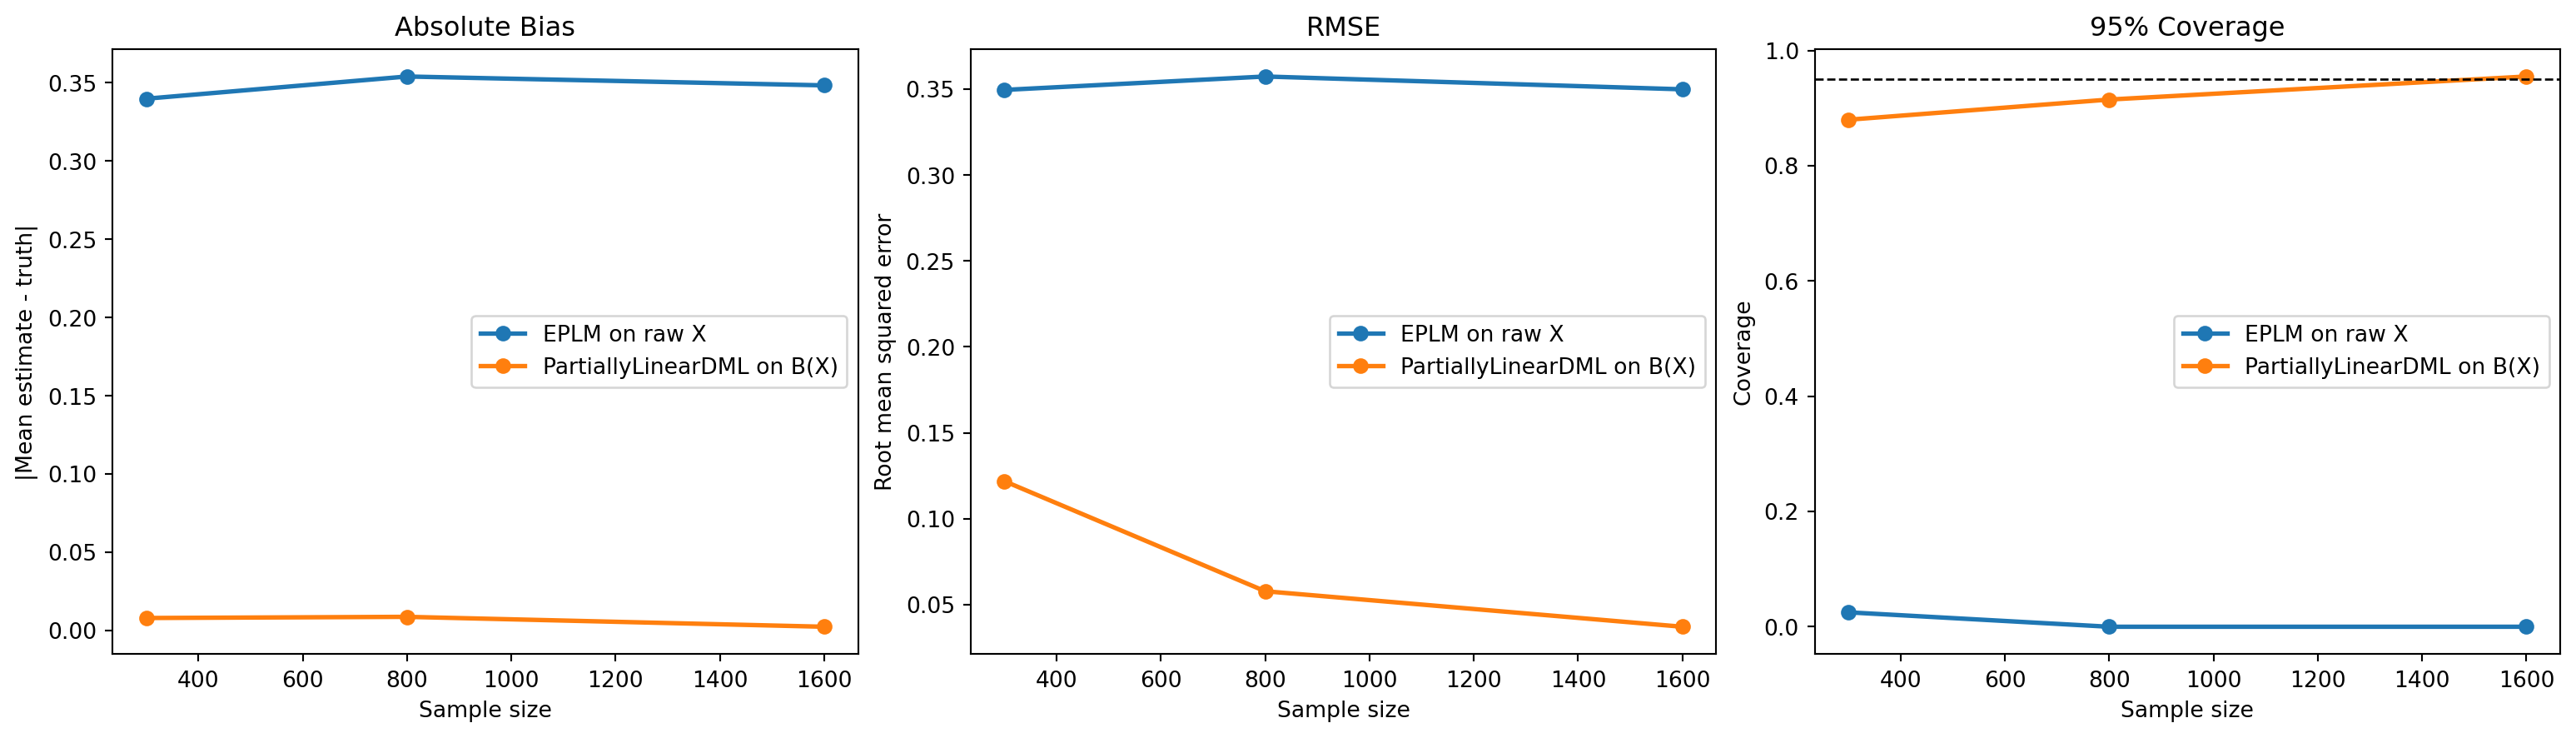

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
plot_metric(axes[0], continuous_results, "abs_bias", "Absolute Bias", "|Mean estimate - truth|")
plot_metric(axes[1], continuous_results, "rmse", "RMSE", "Root mean squared error")
plot_metric(axes[2], continuous_results, "coverage", "95% Coverage", "Coverage")
axes[2].axhline(0.95, color="black", linestyle="--", linewidth=1.0)
plt.show()

In [7]:
from dataclasses import dataclass


@dataclass(frozen=True)
class OutcomeRegime:
    name: str
    label: str
    nonlinearity: str
    prognostic_shape: str
    noise_scale: float


@dataclass(frozen=True)
class AssignmentRegime:
    name: str
    label: str
    overlap: str
    selection_shape: str
    strength: float
    intercept: float
    nonlinear: bool = False


outcome_regimes = [
    OutcomeRegime("linear", "Linear additive", "low", "raw covariates span outcome", 1.00),
    OutcomeRegime("quadratic", "Quadratic curvature", "medium", "squares matter", 1.00),
    OutcomeRegime("interactions", "Interactions", "medium", "cross-products matter", 1.05),
    OutcomeRegime("smooth", "Smooth nonlinear", "high", "sin/exp/tanh features matter", 1.05),
    OutcomeRegime("aligned", "Treatment-aligned confounding", "high", "outcome loads on assignment index", 1.10),
    OutcomeRegime("heteroskedastic", "Heteroskedastic nonlinear", "high", "variance rises in prognostic tails", 1.20),
    OutcomeRegime("sparse_tail", "Sparse tail signal", "very high", "rare tail units are highly prognostic", 1.15),
]

assignment_regimes = [
    AssignmentRegime("random", "Randomized", "excellent", "no selection", 0.0, 0.0),
    AssignmentRegime("weak_balanced", "Weak balanced logit", "excellent", "linear logit", 0.45, 0.0),
    AssignmentRegime("moderate_balanced", "Moderate balanced logit", "good", "linear logit", 0.75, 0.0),
    AssignmentRegime("strong_balanced", "Strong balanced logit", "thin", "linear logit", 1.10, 0.0),
    AssignmentRegime("weak_rare", "Weak rare treatment", "good", "linear logit, low treated share", 0.55, -0.75),
    AssignmentRegime("moderate_rare", "Moderate rare treatment", "thin", "linear logit, low treated share", 0.90, -1.00),
    AssignmentRegime("strong_rare", "Strong rare treatment", "poor", "linear logit, low treated share", 1.20, -1.25),
    AssignmentRegime("weak_common", "Weak common treatment", "good", "linear logit, high treated share", 0.55, 0.75),
    AssignmentRegime("moderate_common", "Moderate common treatment", "thin", "linear logit, high treated share", 0.90, 1.00),
    AssignmentRegime("nonlinear_moderate", "Nonlinear moderate selection", "thin", "misspecified nonlinear logit", 0.80, 0.0, True),
    AssignmentRegime("nonlinear_strong", "Nonlinear strong selection", "poor", "misspecified nonlinear logit", 1.10, -0.25, True),
]


def dgp_characteristics_rows():
    rows = []
    for outcome in outcome_regimes:
        for assignment in assignment_regimes:
            rows.append(
                [
                    f"{outcome.name} × {assignment.name}",
                    outcome.nonlinearity,
                    outcome.prognostic_shape,
                    assignment.overlap,
                    assignment.selection_shape,
                ]
            )
    return rows


display(
    HTML(
        html_table(
            ["DGP", "Outcome nonlinearity", "Prognostic feature", "Overlap", "Selection"],
            dgp_characteristics_rows(),
        )
    )
)

DGP,Outcome nonlinearity,Prognostic feature,Overlap,Selection
linear × random,low,raw covariates span outcome,excellent,no selection
linear × weak_balanced,low,raw covariates span outcome,excellent,linear logit
linear × moderate_balanced,low,raw covariates span outcome,good,linear logit
linear × strong_balanced,low,raw covariates span outcome,thin,linear logit
linear × weak_rare,low,raw covariates span outcome,good,"linear logit, low treated share"
linear × moderate_rare,low,raw covariates span outcome,thin,"linear logit, low treated share"
linear × strong_rare,low,raw covariates span outcome,poor,"linear logit, low treated share"
linear × weak_common,low,raw covariates span outcome,good,"linear logit, high treated share"
linear × moderate_common,low,raw covariates span outcome,thin,"linear logit, high treated share"
linear × nonlinear_moderate,low,raw covariates span outcome,thin,misspecified nonlinear logit


In [8]:
def rich_balance_basis(x):
    x1, x2, x3, x4, x5 = x.T
    return np.column_stack(
        [
            x,
            x**2 - 1.0,
            x1 * x2,
            x1 * x3,
            x2 * x3,
            x3 * x4,
            np.sin(x1),
            np.sin(x5),
            np.exp(0.25 * x1),
            np.tanh(x4),
        ]
    )


def assignment_index(x, regime):
    x1, x2, x3, x4, x5 = x.T
    base = 0.9 * x1 - 0.75 * x2 + 0.55 * x3 - 0.35 * x4 + 0.15 * x5
    if regime.nonlinear:
        base = base + 0.55 * np.sin(x1 * x2) + 0.35 * (x4**2 - 1.0) - 0.25 * np.maximum(x5, 0.0)
    return regime.intercept + regime.strength * base


def untreated_mean(x, outcome, assign_index):
    x1, x2, x3, x4, x5 = x.T
    if outcome.name == "linear":
        return 0.5 + 0.7 * x1 - 0.5 * x2 + 0.35 * x3 + 0.2 * x4
    if outcome.name == "quadratic":
        return 0.5 + 0.5 * x1 - 0.35 * x2 + 0.55 * (x3**2 - 1.0) - 0.45 * (x4**2 - 1.0)
    if outcome.name == "interactions":
        return 0.5 + 0.45 * x1 - 0.35 * x2 + 0.75 * x2 * x3 - 0.55 * x1 * x4 + 0.25 * x5
    if outcome.name == "smooth":
        return 0.5 + 1.0 * np.sin(x1) + 0.8 * np.exp(0.25 * x2) + 0.6 * np.tanh(x3 * x4) + 0.35 * np.sin(x5)
    if outcome.name == "aligned":
        return 0.5 + 0.65 * assign_index + 0.45 * np.sin(x1 * x2) + 0.4 * (x4**2 - 1.0)
    if outcome.name == "heteroskedastic":
        return 0.5 + 0.8 * np.sin(x1) + 0.65 * x2 * x3 + 0.55 * (x4**2 - 1.0) + 0.35 * x5
    if outcome.name == "sparse_tail":
        return 0.5 + 0.45 * x1 - 0.35 * x2 + 1.35 * (x1 > 1.0) * (x3 + 0.5) - 1.0 * (x4 < -1.0)
    raise ValueError(outcome.name)


def binary_grid_dgp(n, rng, outcome, assignment, tau=1.0):
    x = rng.normal(size=(n, 5))
    index = assignment_index(x, assignment)
    pi = expit(index)
    d = rng.binomial(1, pi, size=n).astype(float)
    mu0 = untreated_mean(x, outcome, index)
    if outcome.name == "heteroskedastic":
        sigma = outcome.noise_scale * (0.7 + 0.35 * np.abs(x[:, 0]) + 0.2 * (x[:, 3] > 0.5))
    else:
        sigma = np.full(n, outcome.noise_scale)
    y = mu0 + tau * d + rng.normal(scale=sigma, size=n)
    return y, d, x, pi, tau


def fit_ols_ate(y, d, x):
    model = cm.OLS()
    model.fit(np.column_stack([d, x]), y)
    return float(model.summary(vcov="hc1")["coef"][0])


def fit_oracle_hajek_ate(y, d, pi):
    pi = np.clip(pi, 0.02, 0.98)
    treated = d == 1.0
    control = ~treated
    treated_mean = np.sum(d * y / pi) / np.sum(d / pi)
    control_mean = np.sum((1.0 - d) * y / (1.0 - pi)) / np.sum((1.0 - d) / (1.0 - pi))
    return float(treated_mean - control_mean)


def fit_balancing_ate(y, d, x, objective):
    b = rich_balance_basis(x)
    treated = d == 1.0
    control = ~treated
    if treated.sum() < 5 or control.sum() < 5:
        raise ValueError("too few observations in one treatment arm")
    treated_model = cm.BalancingWeights(objective=objective, solver="auto", autoscale=True, max_iterations=500, tolerance=1e-8)
    control_model = cm.BalancingWeights(objective=objective, solver="auto", autoscale=True, max_iterations=500, tolerance=1e-8)
    treated_model.fit(b[treated], b)
    control_model.fit(b[control], b)
    wt = np.asarray(treated_model.summary()["weights"])
    wc = np.asarray(control_model.summary()["weights"])
    return float(wt @ y[treated] - wc @ y[control])


def fit_aipw_ate(y, d, x, penalty_grid):
    model = cm.AIPW(penalty=penalty_grid, cv=3, n_folds=3, propensity_clip=0.05, seed=19)
    model.fit(y, d, rich_balance_basis(x))
    return float(model.summary(vcov="hc1")["ate"])


def fit_att_aipw(y, d, x, penalty_grid):
    model = cm.ATTAIPW(penalty=penalty_grid, cv=3, n_folds=3, propensity_clip=0.05, seed=23)
    model.fit(y, d, rich_balance_basis(x))
    return float(model.summary(vcov="hc1")["att"])


def summarize_estimates(estimates, truth):
    estimates = np.asarray(estimates, dtype=float)
    err = estimates - truth
    return {
        "mse": float(np.mean(err**2)),
        "mean_abs_bias": float(abs(np.mean(err))),
        "variance": float(np.var(estimates, ddof=1)),
        "success_rate": float(np.isfinite(estimates).mean()),
    }


def simulate_binary_grid(n=700, reps=40, seed=20260516):
    rng = np.random.default_rng(seed)
    penalty_grid = np.logspace(-3, 2, 10)
    methods = [
        ("OLS on [D, X]", lambda y, d, x, pi: fit_ols_ate(y, d, x)),
        ("Hájek IPW, oracle e(X)", lambda y, d, x, pi: fit_oracle_hajek_ate(y, d, pi)),
        ("Entropy balancing on B(X)", lambda y, d, x, pi: fit_balancing_ate(y, d, x, "entropy")),
        ("Quadratic balancing on B(X)", lambda y, d, x, pi: fit_balancing_ate(y, d, x, "quadratic")),
        ("AIPW ATE on B(X)", lambda y, d, x, pi: fit_aipw_ate(y, d, x, penalty_grid)),
        ("ATT AIPW on B(X)", lambda y, d, x, pi: fit_att_aipw(y, d, x, penalty_grid)),
    ]
    rows = []
    for outcome in outcome_regimes:
        for assignment in assignment_regimes:
            estimates = {name: [] for name, _ in methods}
            failures = {name: 0 for name, _ in methods}
            for _ in range(reps):
                y, d, x, pi, tau = binary_grid_dgp(n, rng, outcome, assignment)
                for name, fn in methods:
                    try:
                        estimates[name].append(fn(y, d, x, pi))
                    except Exception:
                        failures[name] += 1
            for name, _ in methods:
                vals = np.asarray(estimates[name], dtype=float)
                if vals.size == 0:
                    stats = {"mse": np.nan, "mean_abs_bias": np.nan, "variance": np.nan, "success_rate": 0.0}
                else:
                    stats = summarize_estimates(vals, tau)
                    stats["success_rate"] = vals.size / reps
                rows.append(
                    {
                        "dgp": f"{outcome.name} × {assignment.name}",
                        "outcome": outcome.label,
                        "nonlinearity": outcome.nonlinearity,
                        "overlap": assignment.overlap,
                        "selection": assignment.selection_shape,
                        "method": name,
                        "failures": failures[name],
                        **stats,
                    }
                )
    return rows


binary_grid_results = simulate_binary_grid()

In [9]:
def group_summary(rows, group_keys):
    grouped = {}
    for row in rows:
        key = tuple(row[k] for k in group_keys)
        grouped.setdefault(key, []).append(row)
    out = []
    for key, vals in grouped.items():
        out.append(
            {
                **{k: key[i] for i, k in enumerate(group_keys)},
                "mse": float(np.nanmean([v["mse"] for v in vals])),
                "mean_abs_bias": float(np.nanmean([v["mean_abs_bias"] for v in vals])),
                "variance": float(np.nanmean([v["variance"] for v in vals])),
                "success_rate": float(np.nanmean([v["success_rate"] for v in vals])),
            }
        )
    return sorted(out, key=lambda r: (r["mse"], r["mean_abs_bias"]))


overall_binary = group_summary(binary_grid_results, ["method"])

display(
    HTML(
        html_table(
            ["Estimator", "Mean MSE", "Mean Absolute Bias", "Mean Variance", "Success rate"],
            [
                [
                    r["method"],
                    f"{r['mse']:.4f}",
                    f"{r['mean_abs_bias']:.4f}",
                    f"{r['variance']:.4f}",
                    f"{r['success_rate']:.3f}",
                ]
                for r in overall_binary
            ],
        )
    )
)

Estimator,Mean MSE,Mean Absolute Bias,Mean Variance,Success rate
Quadratic balancing on B(X),0.0137,0.0192,0.0134,1.000
Entropy balancing on B(X),0.0144,0.0163,0.0144,1.000
AIPW ATE on B(X),0.0181,0.0247,0.0174,1.000
"OLS on [D, X]",0.0226,0.0470,0.0124,1.000
"Hájek IPW, oracle e(X)",0.0242,0.0213,0.0240,1.000
ATT AIPW on B(X),0.0252,0.0264,0.0244,1.000


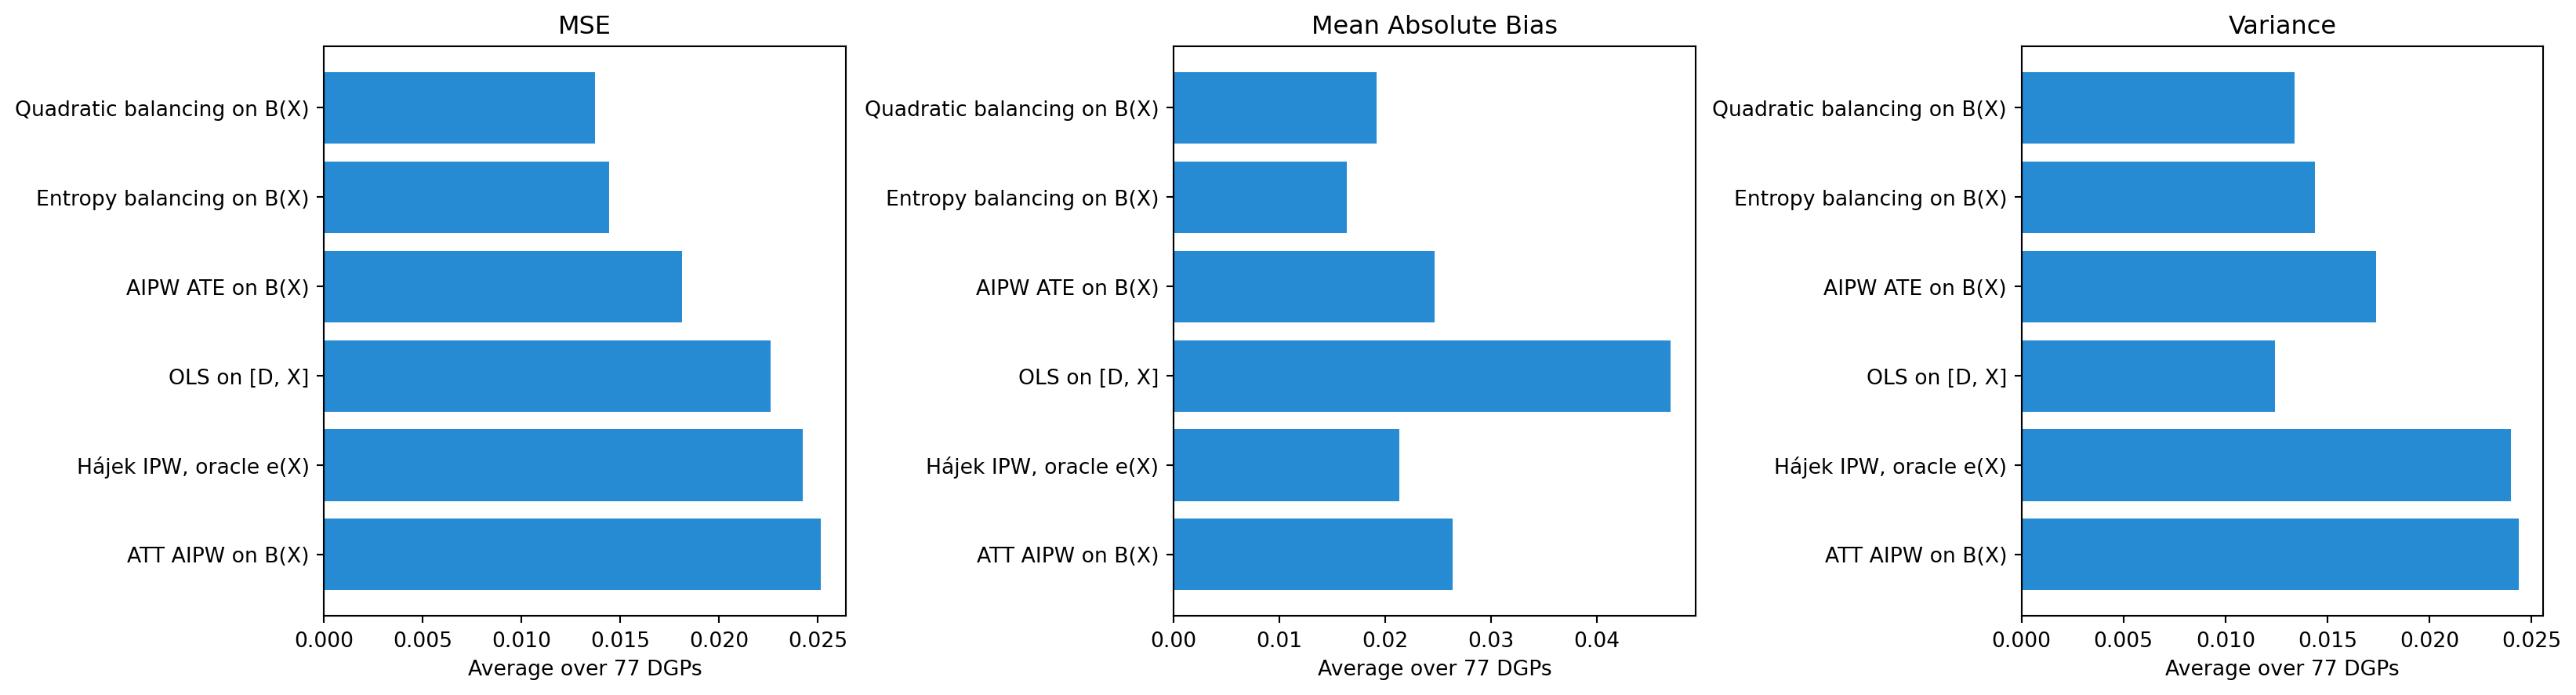

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
metrics = [("mse", "MSE"), ("mean_abs_bias", "Mean Absolute Bias"), ("variance", "Variance")]
methods = [r["method"] for r in overall_binary]
for ax, (metric, title) in zip(axes, metrics):
    vals = [r[metric] for r in overall_binary]
    ax.barh(methods, vals, color="#268bd2")
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Average over 77 DGPs")
plt.show()

In [11]:
for characteristic in ["nonlinearity", "overlap"]:
    characteristic_summary = group_summary(binary_grid_results, [characteristic, "method"])
    display(HTML(f"<h4>Grouped by {escape(characteristic)}</h4>"))
    display(
        HTML(
            html_table(
                [characteristic.title(), "Estimator", "Mean MSE", "Mean Absolute Bias", "Mean Variance"],
                [
                    [
                        r[characteristic],
                        r["method"],
                        f"{r['mse']:.4f}",
                        f"{r['mean_abs_bias']:.4f}",
                        f"{r['variance']:.4f}",
                    ]
                    for r in characteristic_summary
                ],
            )
        )
    )

Nonlinearity,Estimator,Mean MSE,Mean Absolute Bias,Mean Variance
low,"OLS on [D, X]",0.0068,0.0081,0.0069
low,Entropy balancing on B(X),0.0100,0.0109,0.0101
low,Quadratic balancing on B(X),0.0101,0.0095,0.0103
medium,Quadratic balancing on B(X),0.0133,0.0178,0.0132
high,Quadratic balancing on B(X),0.0140,0.0189,0.0136
medium,Entropy balancing on B(X),0.0142,0.0167,0.0142
low,AIPW ATE on B(X),0.0142,0.0308,0.0129
very high,"OLS on [D, X]",0.0147,0.0421,0.0125
high,Entropy balancing on B(X),0.0154,0.0182,0.0152
low,ATT AIPW on B(X),0.0158,0.0249,0.0152


Overlap,Estimator,Mean MSE,Mean Absolute Bias,Mean Variance
excellent,Entropy balancing on B(X),0.0083,0.0133,0.0083
excellent,Quadratic balancing on B(X),0.0084,0.0117,0.0084
good,Entropy balancing on B(X),0.0101,0.0126,0.0102
good,Quadratic balancing on B(X),0.0103,0.0152,0.0102
excellent,"OLS on [D, X]",0.0103,0.0137,0.0103
good,"OLS on [D, X]",0.0108,0.0131,0.0108
excellent,AIPW ATE on B(X),0.0113,0.0143,0.0113
excellent,"Hájek IPW, oracle e(X)",0.0127,0.0099,0.0129
excellent,ATT AIPW on B(X),0.0134,0.0166,0.0133
good,AIPW ATE on B(X),0.0142,0.0146,0.0142
